<a href="https://colab.research.google.com/github/dhanalakshmirose/Employee-Attrition-Analysis/blob/main/mlda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SETUP

In [1]:
!pip install shap catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             precision_score, recall_score, f1_score, classification_report,
                             precision_recall_curve, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

SEED = 42
sns.set_style("whitegrid")

1. LOAD & BASIC CLEANING

In [3]:
PATH = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(PATH)

print(df.shape)
print(df.isnull().sum().sum(), "missing values |", df.duplicated().sum(), "duplicate rows")
df.info()
display(df.describe().T)

# Constant / useless columns (EmployeeNumber is kept as an ID for the Power BI export)
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

# Target: Yes -> 1, No -> 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df['Attrition'].value_counts(normalize=True).round(3))

cat_cols = df.select_dtypes('object').columns.tolist()
num_cols = [c for c in df.select_dtypes('number').columns if c not in ['Attrition', 'EmployeeNumber']]

(1470, 35)
0 missing values | 0 duplicate rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


Attrition
0    0.839
1    0.161
Name: proportion, dtype: float64


2. EDA

   2a. Attrition rate by categorical feature

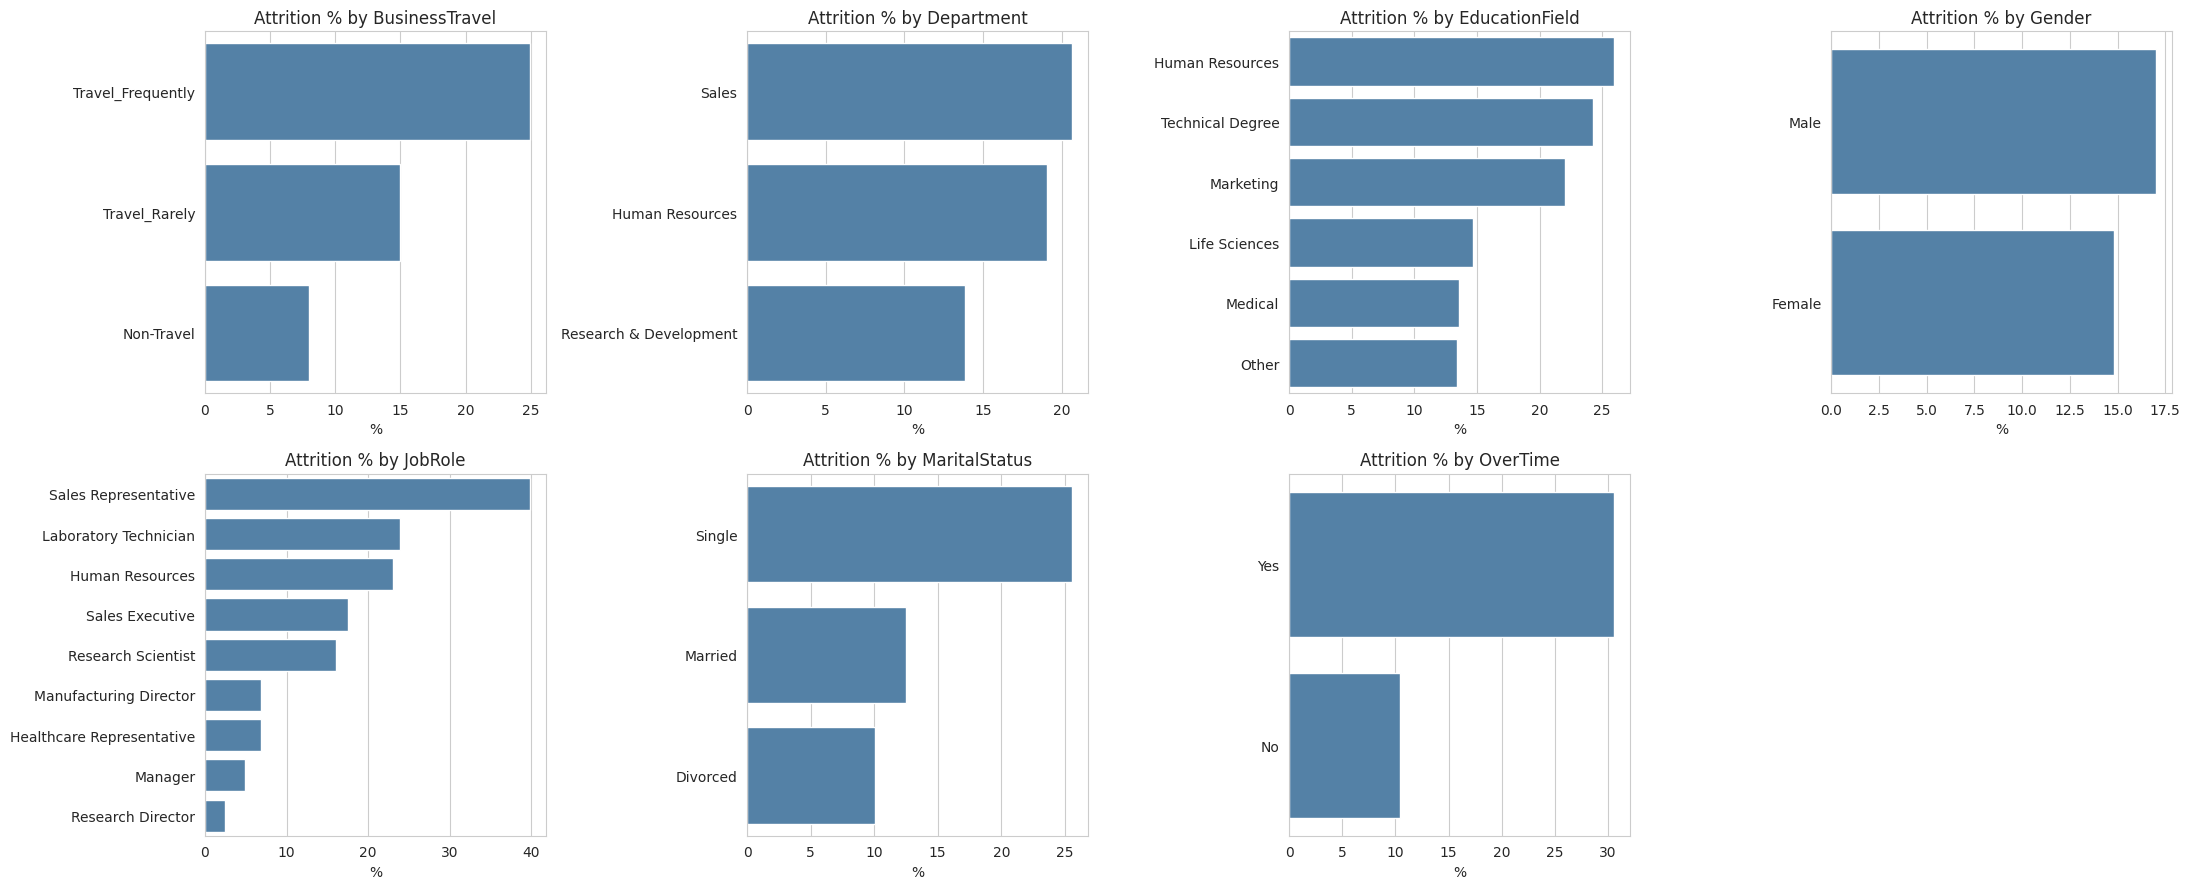

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = df.groupby(col)['Attrition'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color="steelblue")
    ax.set_title(f"Attrition % by {col}"); ax.set_xlabel("%"); ax.set_ylabel("")
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

 2b. Numeric distributions split by Attrition

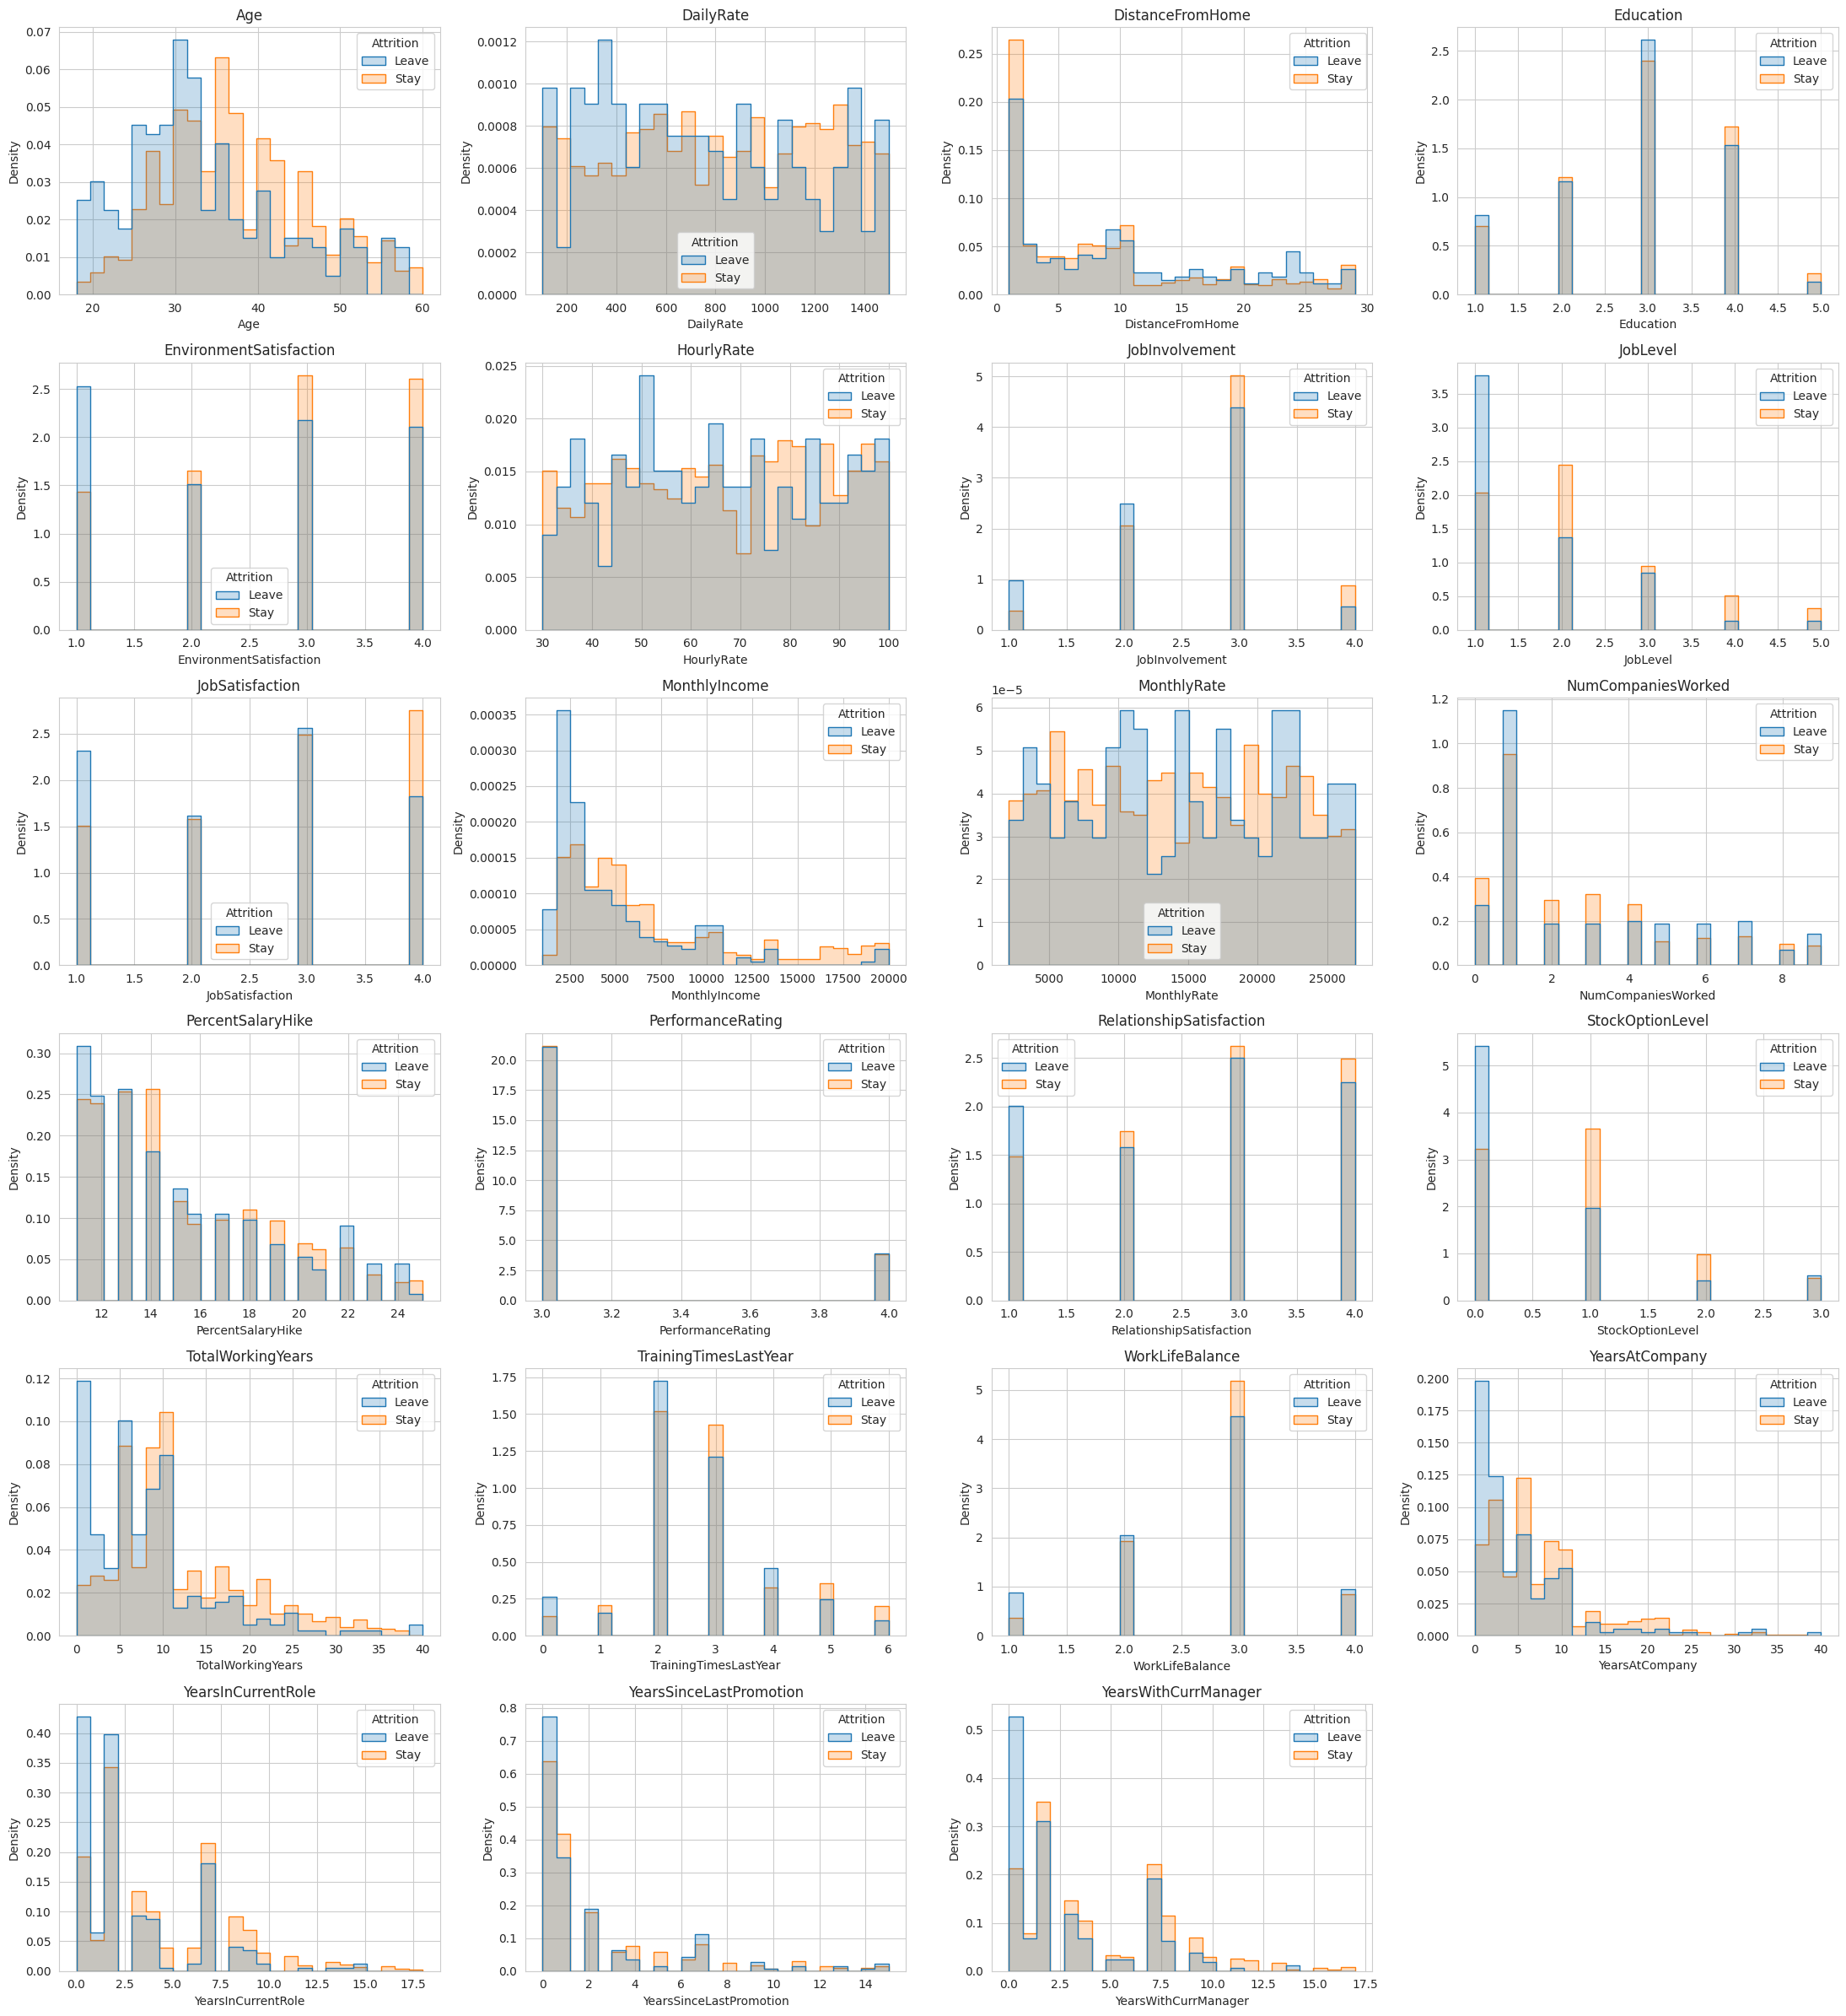

In [5]:
lab = df['Attrition'].map({0: 'Stay', 1: 'Leave'})
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 4 * nrows))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(x=df[col], hue=lab, bins=25, element="step", stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(col)
for ax in axes.ravel()[len(num_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

2c. Top correlations with Attrition (numeric only)

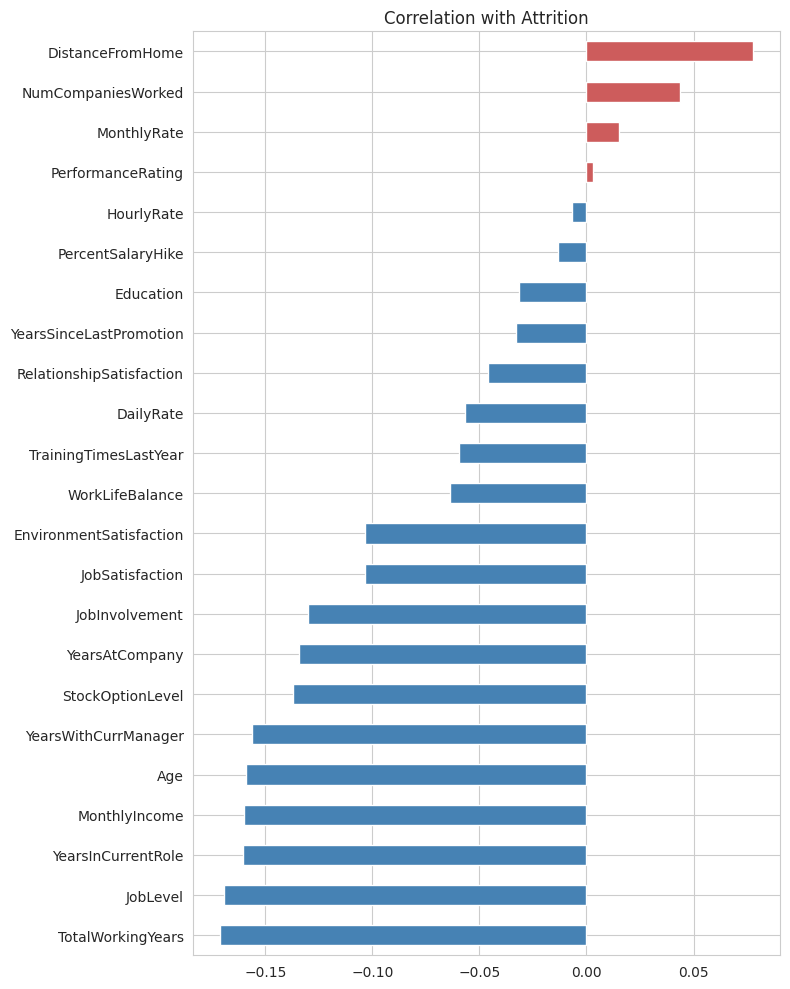

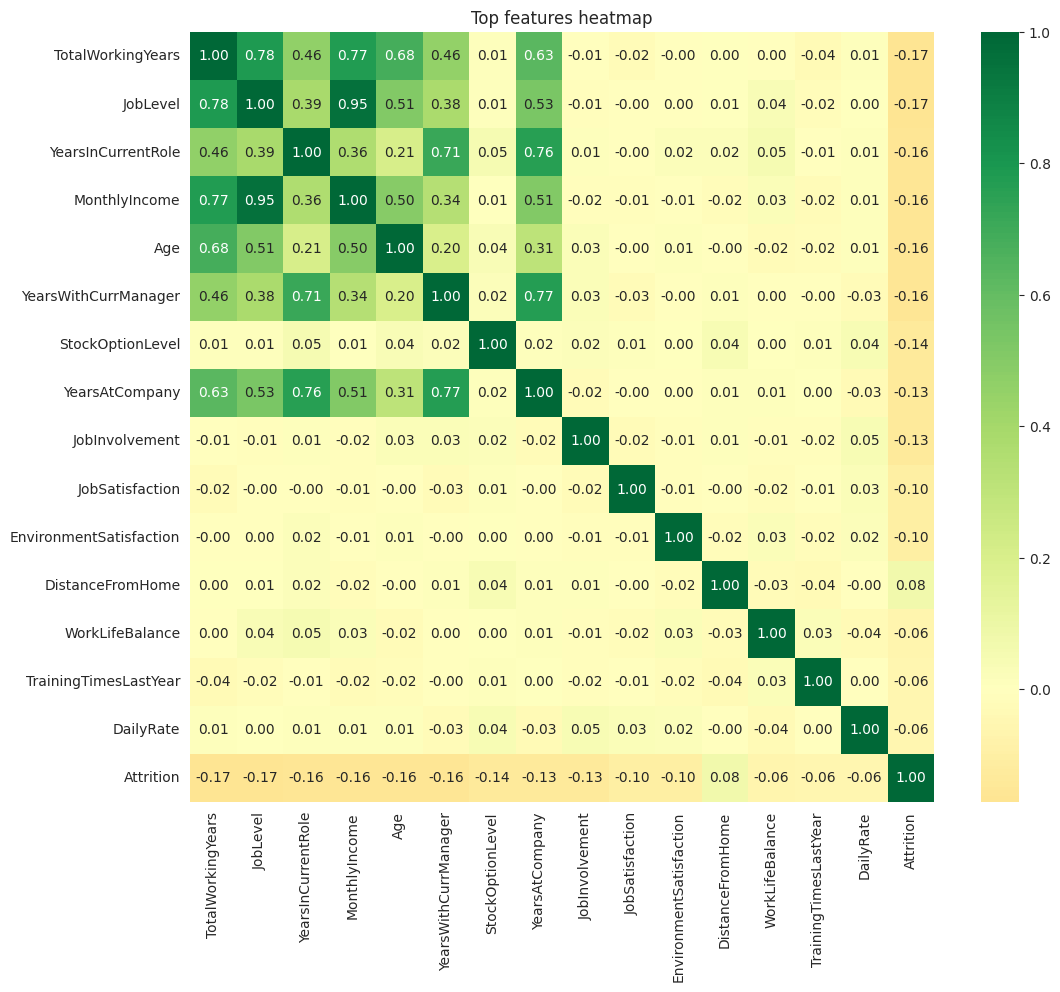

In [6]:
corr = df[num_cols + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values()
plt.figure(figsize=(8, 10))
corr.plot(kind='barh', color=np.where(corr > 0, 'indianred', 'steelblue'))
plt.title("Correlation with Attrition"); plt.tight_layout(); plt.show()

top = corr.abs().sort_values(ascending=False).head(15).index.tolist() + ['Attrition']
plt.figure(figsize=(12, 10))
sns.heatmap(df[top].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Top features heatmap"); plt.show()

3. FEATURE ENGINEERING

In [7]:
df['IncomeToLevel']     = df['MonthlyIncome'] / df['JobLevel']
df['PromoRatio']        = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['TenureRatio']       = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['CompaniesPerYear']  = df['NumCompaniesWorked'] / (df['TotalWorkingYears'] + 1)
df['OT_LowSatisfaction'] = ((df['OverTime'] == 'Yes') & (df['JobSatisfaction'] <= 2)).astype(int)

4. ENCODING (only true nominal columns are one-hot encoded;

   ordinal ratings like Education / JobSatisfaction stay numeric)

In [8]:
ids = df['EmployeeNumber']
y = df['Attrition']
X = pd.get_dummies(df.drop(columns=['Attrition', 'EmployeeNumber']),
                   columns=cat_cols, drop_first=True, dtype=int).astype(float)
X = X.loc[:, X.nunique() > 1]          # drop constant columns, if any
print("Feature matrix:", X.shape)

Feature matrix: (1470, 49)


5. TRAIN / TEST SPLIT (stratified)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)

print(f"Leave rate  train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")
print(f"Baseline accuracy (always 'stay'): {1 - y_test.mean():.2%}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

Leave rate  train: 16.13% | test: 16.10%
Baseline accuracy (always 'stay'): 83.90%


6. HYPERPARAMETER TUNING (on TRAIN only, CV-based)

6a. Logistic Regression

In [10]:
lr_pipe = Pipeline([('sc', StandardScaler()),
                    ('m', LogisticRegression(max_iter=3000, class_weight='balanced'))])
lr_search = GridSearchCV(lr_pipe, {'m__C': [0.003, 0.01, 0.03, 0.1, 0.3, 1, 3]},
                         scoring='roc_auc', cv=cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
print("LogReg best:", lr_search.best_params_, round(lr_search.best_score_, 4))

LogReg best: {'m__C': 0.03} 0.8256


6b. Random Forest

In [11]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced_subsample', random_state=SEED, n_jobs=-1),
    {'n_estimators': [200, 400, 600],
     'max_depth': [4, 6, 8, 12, None],
     'min_samples_split': [2, 5, 10],
     'min_samples_leaf': [1, 2, 4, 6],
     'max_features': ['sqrt', 'log2', 0.3]},
    n_iter=30, scoring='roc_auc', cv=cv, random_state=SEED, n_jobs=-1)
rf_search.fit(X_train, y_train)
print("RF best:", rf_search.best_params_, round(rf_search.best_score_, 4))

RF best: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.3, 'max_depth': 12} 0.8126


 7. MODEL DEFINITIONS (class imbalance handled in every model)

In [12]:
models = {
    'Logistic Regression': lr_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'SVM': Pipeline([('sc', StandardScaler()),
                     ('m', SVC(C=1, class_weight='balanced', probability=True, random_state=SEED))]),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                             subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=neg / pos, eval_metric='logloss',
                             random_state=SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                               class_weight='balanced', random_state=SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=400, learning_rate=0.05, depth=4,
                                   auto_class_weights='Balanced', verbose=0,
                                   random_seed=SEED, allow_writing_files=False),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=SEED),
}

8. CROSS-VALIDATED COMPARISON (train set) -> pick best model

In [13]:
scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision',
           'recall': 'recall', 'precision': 'precision', 'f1': 'f1'}

cv_rows = {}
for name, m in models.items():
    r = cross_validate(m, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows[name] = {k[5:]: v.mean() for k, v in r.items() if k.startswith('test_')}
cv_results = pd.DataFrame(cv_rows).T.sort_values('roc_auc', ascending=False).round(3)
print("\n=== 5-FOLD CV RESULTS (train set) ===")
display(cv_results)

best_name = cv_results['roc_auc'].idxmax()
best_model = models[best_name]
print("Best model by CV ROC-AUC:", best_name)


=== 5-FOLD CV RESULTS (train set) ===


,roc_auc,pr_auc,recall,precision,f1
Logistic Regression,0.826,0.612,0.735,0.390,0.509
AdaBoost,0.825,0.642,0.361,0.808,0.497
SVM,0.821,0.606,0.573,0.532,0.552
Random Forest,0.813,0.566,0.337,0.641,0.439
LightGBM,0.812,0.586,0.440,0.609,0.509
XGBoost,0.808,0.593,0.519,0.570,0.540
CatBoost,0.807,0.615,0.500,0.655,0.566


Best model by CV ROC-AUC: Logistic Regression


 9. HONEST TEST-SET EVALUATION (probabilities, not hard labels)


=== TEST SET RESULTS (threshold = 0.5) ===


,roc_auc,pr_auc,accuracy,precision,recall,f1
Logistic Regression,0.803,0.576,0.778,0.390,0.676,0.495
SVM,0.792,0.515,0.862,0.679,0.268,0.384
AdaBoost,0.783,0.459,0.844,0.531,0.239,0.330
CatBoost,0.770,0.515,0.825,0.450,0.380,0.412
XGBoost,0.761,0.479,0.810,0.408,0.408,0.408
LightGBM,0.749,0.450,0.837,0.489,0.324,0.390
Random Forest,0.738,0.375,0.832,0.459,0.239,0.315


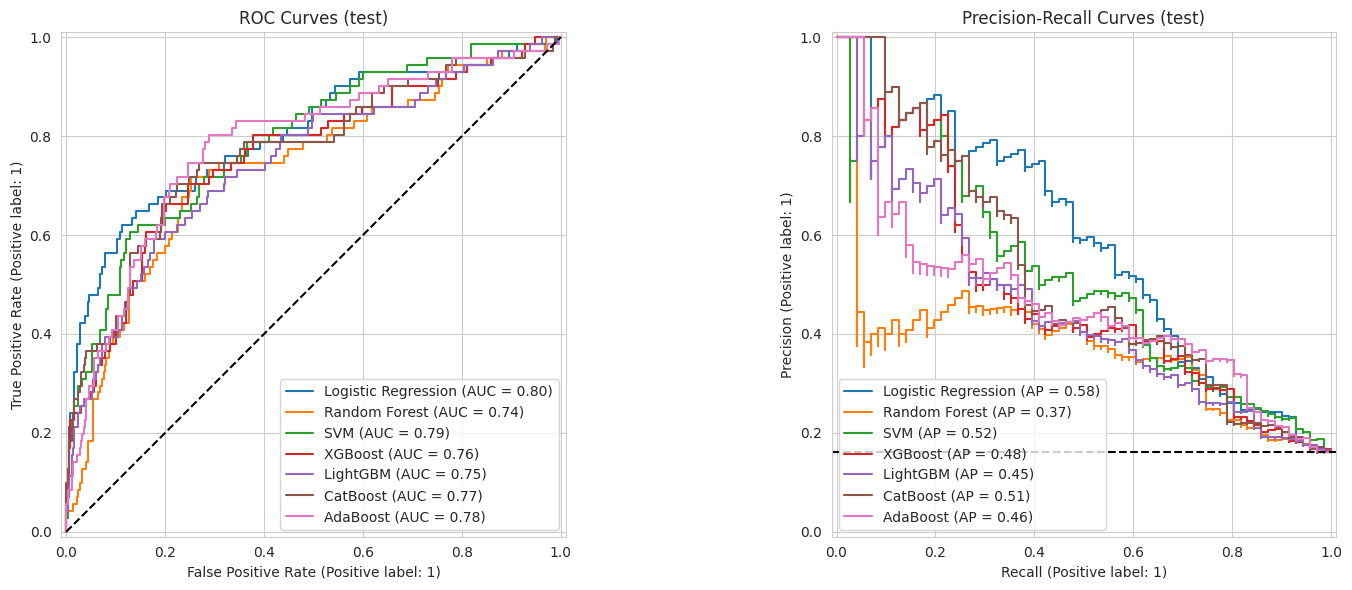

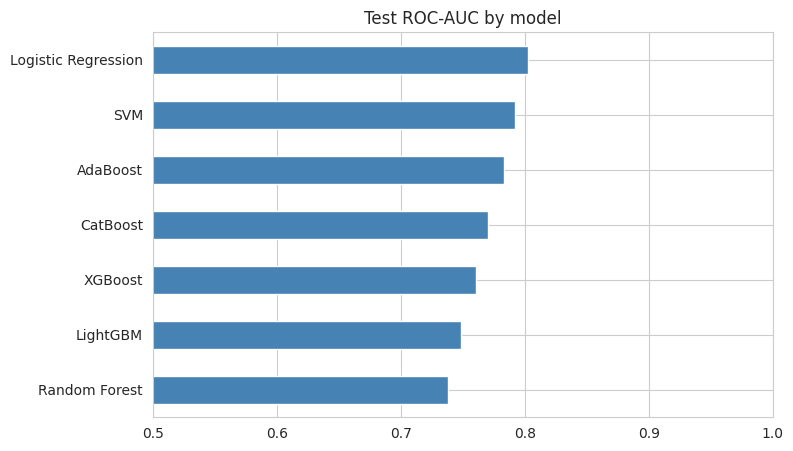

In [14]:
def get_metrics(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {'roc_auc': roc_auc_score(y_true, proba),
            'pr_auc': average_precision_score(y_true, proba),
            'accuracy': accuracy_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred),
            'f1': f1_score(y_true, pred)}

test_proba, test_rows = {}, {}
for name, m in models.items():
    m.fit(X_train, y_train)
    test_proba[name] = m.predict_proba(X_test)[:, 1]
    test_rows[name] = get_metrics(y_test, test_proba[name])
test_results = pd.DataFrame(test_rows).T.sort_values('roc_auc', ascending=False).round(3)
print("\n=== TEST SET RESULTS (threshold = 0.5) ===")
display(test_results)

# ROC + PR curves for all models
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for name, p in test_proba.items():
    RocCurveDisplay.from_predictions(y_test, p, name=name, ax=ax[0])
    PrecisionRecallDisplay.from_predictions(y_test, p, name=name, ax=ax[1])
ax[0].plot([0, 1], [0, 1], 'k--'); ax[0].set_title("ROC Curves (test)")
ax[1].axhline(y_test.mean(), color='k', ls='--'); ax[1].set_title("Precision-Recall Curves (test)")
plt.tight_layout(); plt.show()

# Bar chart of ROC-AUC
test_results['roc_auc'].sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Test ROC-AUC by model"); plt.xlim(0.5, 1); plt.show()

10. THRESHOLD TUNING (chosen on train out-of-fold, applied to test)

     F2 weights recall higher: missing a leaver costs more than a false alarm


Chosen threshold for Logistic Regression: 0.496
              precision    recall  f1-score   support

        Stay       0.93      0.79      0.85       370
       Leave       0.39      0.69      0.49        71

    accuracy                           0.77       441
   macro avg       0.66      0.74      0.67       441
weighted avg       0.84      0.77      0.80       441



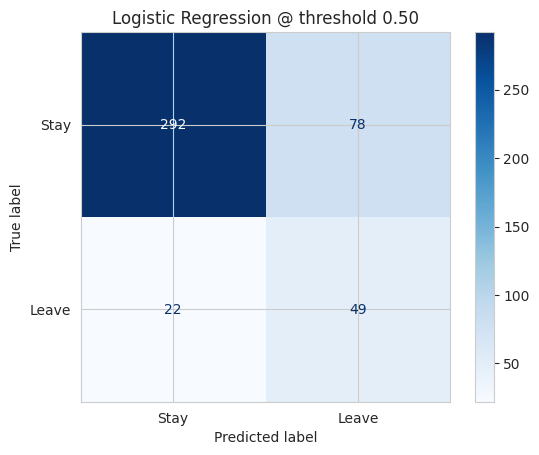

In [15]:
oof_train = cross_val_predict(best_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
p, r, t = precision_recall_curve(y_train, oof_train)
f2 = (5 * p * r) / (4 * p + r + 1e-9)
thr = float(t[np.argmax(f2[:-1])])
print(f"\nChosen threshold for {best_name}: {thr:.3f}")

best_model.fit(X_train, y_train)
final_proba = best_model.predict_proba(X_test)[:, 1]
final_pred = (final_proba >= thr).astype(int)

print(classification_report(y_test, final_pred, target_names=['Stay', 'Leave']))
ConfusionMatrixDisplay.from_predictions(y_test, final_pred, display_labels=['Stay', 'Leave'],
                                        cmap='Blues')
plt.title(f"{best_name} @ threshold {thr:.2f}"); plt.show()

11. INTERPRETABILITY

11a. Logistic Regression odds ratios (easy to explain to non-technical people)


Top drivers that INCREASE attrition odds (per 1 std dev):


,0
OverTime_Yes,1.66
BusinessTravel_Travel_Frequently,1.44
YearsSinceLastPromotion,1.39
JobRole_Laboratory Technician,1.39
MaritalStatus_Single,1.33
CompaniesPerYear,1.29
DistanceFromHome,1.25
JobRole_Sales Representative,1.24
BusinessTravel_Travel_Rarely,1.18
NumCompaniesWorked,1.18


Top drivers that DECREASE attrition odds:


,0
YearsInCurrentRole,0.85
TotalWorkingYears,0.84
JobRole_Research Director,0.84
IncomeToLevel,0.82
JobInvolvement,0.81
StockOptionLevel,0.81
Age,0.79
JobSatisfaction,0.78
RelationshipSatisfaction,0.76
EnvironmentSatisfaction,0.75


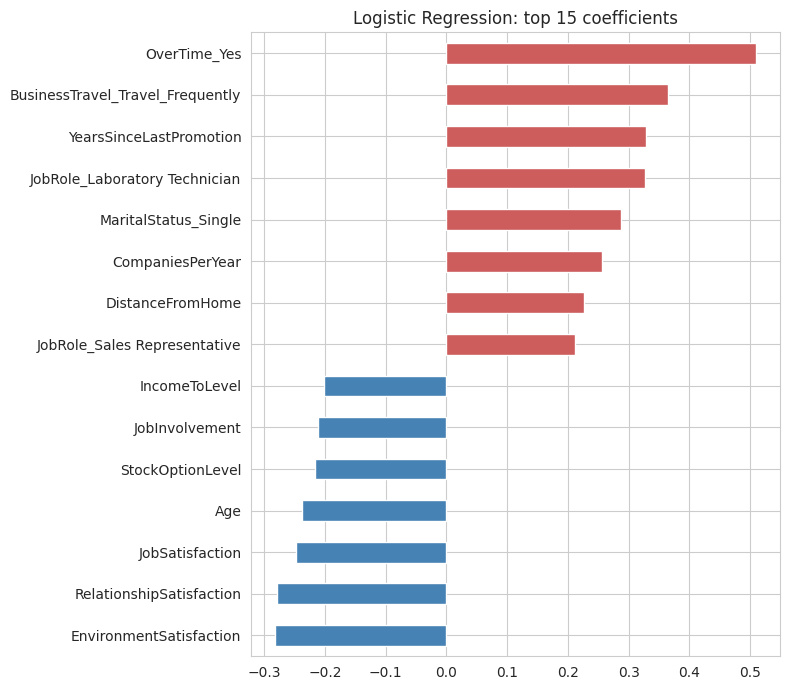

In [16]:
lr_fit = models['Logistic Regression']
coefs = pd.Series(lr_fit.named_steps['m'].coef_[0], index=X.columns)
odds = np.exp(coefs).sort_values(ascending=False)
print("\nTop drivers that INCREASE attrition odds (per 1 std dev):")
display(odds.head(10).round(2))
print("Top drivers that DECREASE attrition odds:")
display(odds.tail(10).round(2))

top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index).sort_values()
top_coefs.plot(kind='barh', figsize=(8, 7),
               color=np.where(top_coefs > 0, 'indianred', 'steelblue'))
plt.title("Logistic Regression: top 15 coefficients"); plt.tight_layout(); plt.show()

11b. Random Forest feature importance

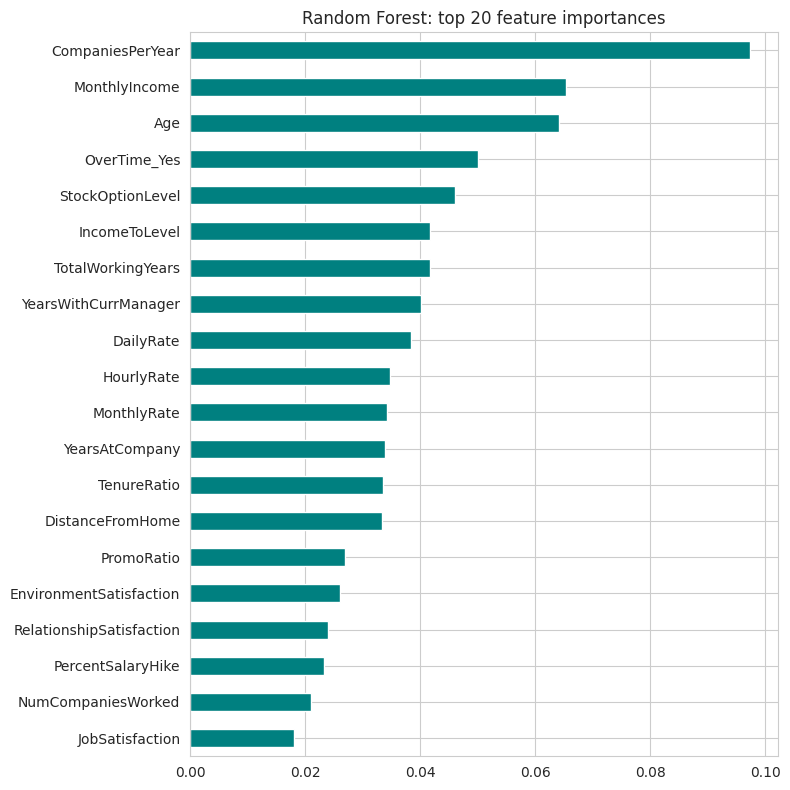

In [17]:
rf_best = models['Random Forest']
imp = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values().tail(20)
imp.plot(kind='barh', figsize=(8, 8), color='teal')
plt.title("Random Forest: top 20 feature importances"); plt.tight_layout(); plt.show()


11c. SHAP (on Random Forest)

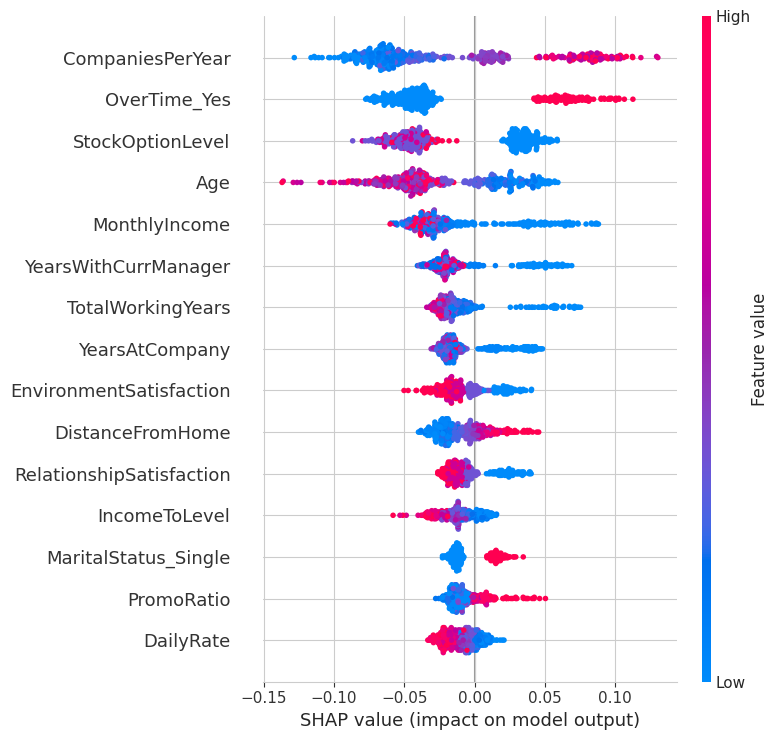

In [18]:
try:
    import shap
    sv = shap.TreeExplainer(rf_best).shap_values(X_test)
    sv1 = sv[1] if isinstance(sv, list) else (sv[..., 1] if sv.ndim == 3 else sv)
    shap.summary_plot(sv1, X_test, max_display=15)
except Exception as e:
    print("SHAP skipped:", e)

 12. EXPORTS FOR POWER BI

In [19]:
from sklearn.model_selection import cross_val_predict

# Out-of-fold probabilities for ALL employees (no employee is scored by a model that saw them)
oof_all = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba')[:, 1]

risk = pd.DataFrame({'EmployeeNumber': ids.values,
                     'Attrition_Prob': oof_all.round(4),
                     'Predicted_Leave': (oof_all >= thr).astype(int),
                     'Actual_Attrition': y.values})
risk['Attrition_Label'] = risk['Actual_Attrition'].map({1: 'Yes', 0: 'No'})
risk['Risk_Band'] = pd.cut(risk['Attrition_Prob'], [0, thr / 2, thr, 1.0001],
                           labels=['Low', 'Medium', 'High'], include_lowest=True).astype(str)
risk['Risk_Order'] = risk['Risk_Band'].map({'Low': 1, 'Medium': 2, 'High': 3})

# Add readable columns so the dashboard can slice by them
context_cols = ['EmployeeNumber', 'Department', 'JobRole', 'Age', 'Gender', 'MaritalStatus',
                'BusinessTravel', 'OverTime', 'MonthlyIncome', 'JobLevel', 'JobSatisfaction',
                'EnvironmentSatisfaction', 'WorkLifeBalance', 'StockOptionLevel',
                'DistanceFromHome', 'YearsAtCompany', 'YearsSinceLastPromotion', 'TotalWorkingYears']
risk = risk.merge(df[context_cols], on='EmployeeNumber', how='left')

# Bands for charts
risk['Age_Group'] = pd.cut(risk['Age'], [17, 25, 35, 45, 55, 100],
                           labels=['18-25', '26-35', '36-45', '46-55', '56+']).astype(str)
risk['Income_Band'] = pd.cut(risk['MonthlyIncome'], [0, 3000, 6000, 10000, 100000],
                             labels=['1) <3K', '2) 3-6K', '3) 6-10K', '4) 10K+']).astype(str)
risk['Tenure_Band'] = pd.cut(risk['YearsAtCompany'], [-1, 2, 5, 10, 100],
                             labels=['1) 0-2 yrs', '2) 3-5 yrs', '3) 6-10 yrs', '4) 10+ yrs']).astype(str)

risk.to_csv("attrition_risk_scores.csv", index=False)

# Model comparison tables for the "Model Insights" page
test_results.reset_index().rename(columns={'index': 'Model'}).to_csv("model_metrics_test.csv", index=False)
cv_results.reset_index().rename(columns={'index': 'Model'}).to_csv("model_metrics_cv.csv", index=False)
odds.reset_index().rename(columns={'index': 'Feature', 0: 'OddsRatio'}).to_csv("lr_odds_ratios.csv", index=False)

print("\nRisk band counts:\n", risk['Risk_Band'].value_counts())
print("Saved: attrition_risk_scores.csv, model_metrics_test.csv, model_metrics_cv.csv, lr_odds_ratios.csv")


Risk band counts:
 Risk_Band
Low       566
High      461
Medium    443
Name: count, dtype: int64
Saved: attrition_risk_scores.csv, model_metrics_test.csv, model_metrics_cv.csv, lr_odds_ratios.csv
